# I-ROCKET Demo: GunPoint Dataset (UCR Archive)

This notebook demonstrates I-ROCKET on the GunPoint dataset from the UCR Time Series Classification Archive. GunPoint is a two-class problem: subjects either draw a gun from a hip holster or simply point their finger. The time series are centroid-y coordinates of the right hand extracted from video, with 150 timepoints per trial.

GunPoint is a useful test case because the class-discriminative signal is a smooth, distributed shape difference (the hand trajectory differs during the draw/return phase) rather than a localized spike.

The aeon package is required for this notebook: https://www.aeon-toolkit.org/en/stable/installation.html

## 0. Setup

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
FIG_WIDTH = 8

## 1. Load and visualize data

In [2]:
from aeon.datasets import load_classification

X, y = load_classification("GunPoint")
X = np.squeeze(X)
y = np.where(y == '1', 0, 1)
print(f"Dataset: {X.shape[0]} instances x {X.shape[1]} timepoints, 2 classes")

Dataset: 200 instances x 150 timepoints, 2 classes


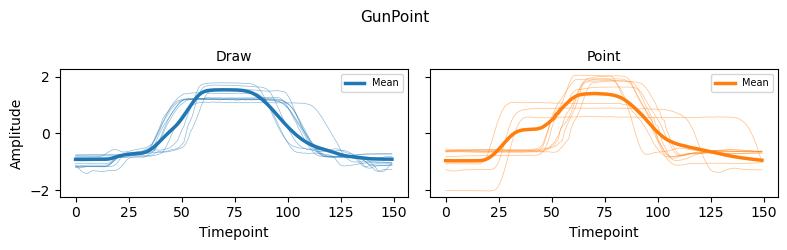

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.5), sharey=True)
class_names = ["Draw", "Point"]
colors = ["tab:blue", "tab:orange"]

for k in range(2):
    ax = axes[k]
    mask = y == k
    for i in np.where(mask)[0][:10]:
        ax.plot(X[i], color=colors[k], alpha=0.5, linewidth=0.5)
    ax.plot(X[mask].mean(axis=0), color=colors[k], linewidth=2.5, label="Mean")
    ax.set_title(class_names[k], fontsize=10)
    ax.set_xlabel("Timepoint")
    if k == 0:
        ax.set_ylabel("Amplitude")
    ax.legend(fontsize=7)

fig.suptitle("GunPoint", fontsize=11)
plt.tight_layout()

## 2. Cross-validation

In [4]:
import interp_rocket_260407 as IR

results = IR.cross_validate(
    X, y,
    n_repeats=5,
    n_folds=5,
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)

print(f"\n5x5 Cross-validation results:")
for metric in ['accuracy', 'balanced_accuracy', 'mcc']:
    m = results[metric]
    print(f"  {metric:>20s}: {m['mean']:.4f} +/- {m['std']:.4f}")

Cross-validation: 5 repeats × 5 folds = 25 evaluations
  Data: 200 instances × 150 timepoints, 2 classes
  Class counts: {np.int64(0): 100, np.int64(1): 100}
  Repeat  1/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  2/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  3/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  4/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  5/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000

  Results (mean ± std across 25 folds):
    accuracy            : 1.0000 ± 0.0000
    balanced_accuracy   : 1.0000 ± 0.0000
    f1_macro            : 1.0000 ± 0.0000
    f1_weighted         : 1.0000 ± 0.0000
    mcc                 : 1.0000 ± 0.0000
    mutual_info         : 1.0000 ± 0.0000

  Aggregated confusion matrix:
            0       1
     0     500       0
     1       0     500

5x5 Cross-validation results:
              accuracy: 1.0000 +/- 0.0000
     balanced_accuracy: 1.0000 +/- 0.0000
                   mcc: 1.0000 +/-

## 3. Feature stability analysis

InterpRocket.fit: 200 instances × 150 timepoints
  Classes: [0 1]
  Fitting dilations (raw)...
  Fitting biases (raw): 3108 biases across 5 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 3108 biases across 5 dilations...
  Transforming training data...
  Feature matrix: (200, 24864)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000
CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 150 features appeared in every round so far
  Round 2/5: 109 features appeared in every round so far
  Round 3/5: 96 features appeared in every round so far
  Round 4/5: 90 features appeared in every round so far
  Round 5/5: 84 features appeared in every round so far

  Features in ALL folds:  1
  Features in ≥80% folds: 6
  Features in NO folds:   24551
Stable features (≥80% of 25 folds): 6


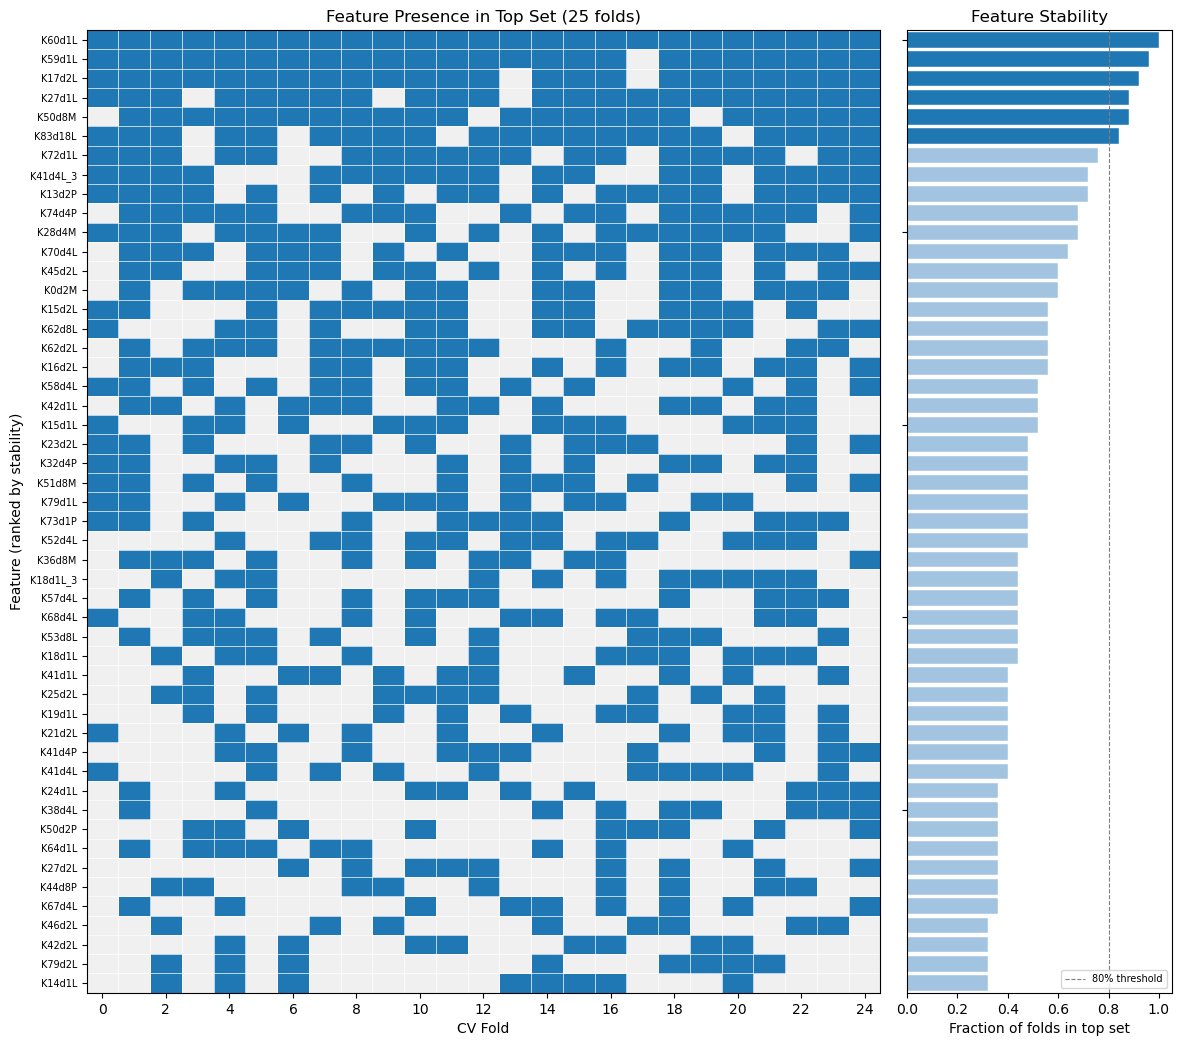

In [5]:
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

stable_features = IR.get_stable_features(stability, threshold=0.8)

### Information decomposition

In [6]:
info = IR.information_decomposition(
    model, X, y,
    group_by='kernel',
    n_shuffles=100,
    feature_mask=stable_features,
)

Information decomposition: 6 features in 6 groups (kernel)
  Ensemble MI: 1.0000 bits
  Group 1/6: I_single=0.1828, I_loo=0.6532
  Group 2/6: I_single=0.3302, I_loo=0.5255
  Group 3/6: I_single=0.0760, I_loo=0.6532
  Group 4/6: I_single=0.1511, I_loo=0.7356
  Group 5/6: I_single=0.0811, I_loo=0.6930
  Group 6/6: I_single=0.1452, I_loo=0.4858
  Computing null distribution (100 shuffles)...

  Results (6 groups):
    Redundant:   0 (0.0%)
    Synergistic: 0 (0.0%)
    Independent: 6 (100.0%)
    Shuffle MI:  0.2353 ± 0.1974
    Ensemble MI: 1.0000
    Sum(I_single): 0.9664
    P_ensemble (I_ens - sum(I_single)): 0.0336


## 4. Interpretability

### Stable features

In [7]:
top = model.get_top_features(feature_mask=stable_features)
for f in top:
    print(f"feature_index={f['feature_index']:>5d}  "
          f"kernel={f['kernel_index']:>2d}  d={f['dilation']:>3d}  "
          f"{f['pooling_op']:>4s}  {f['representation']:>4s}  "
          f"imp={f['importance']:.4f}")

feature_index=14091  kernel=59  d=  1  LSPV  diff  imp=1.0000
feature_index=14135  kernel=60  d=  1  LSPV  diff  imp=0.9175
feature_index=15271  kernel=17  d=  2  LSPV  diff  imp=0.8713
feature_index=21242  kernel=50  d=  8  MIPV  diff  imp=0.8618
feature_index=24863  kernel=83  d= 18  LSPV  diff  imp=0.8598
feature_index=  771  kernel=27  d=  1  LSPV   raw  imp=0.7598


### Top kernels

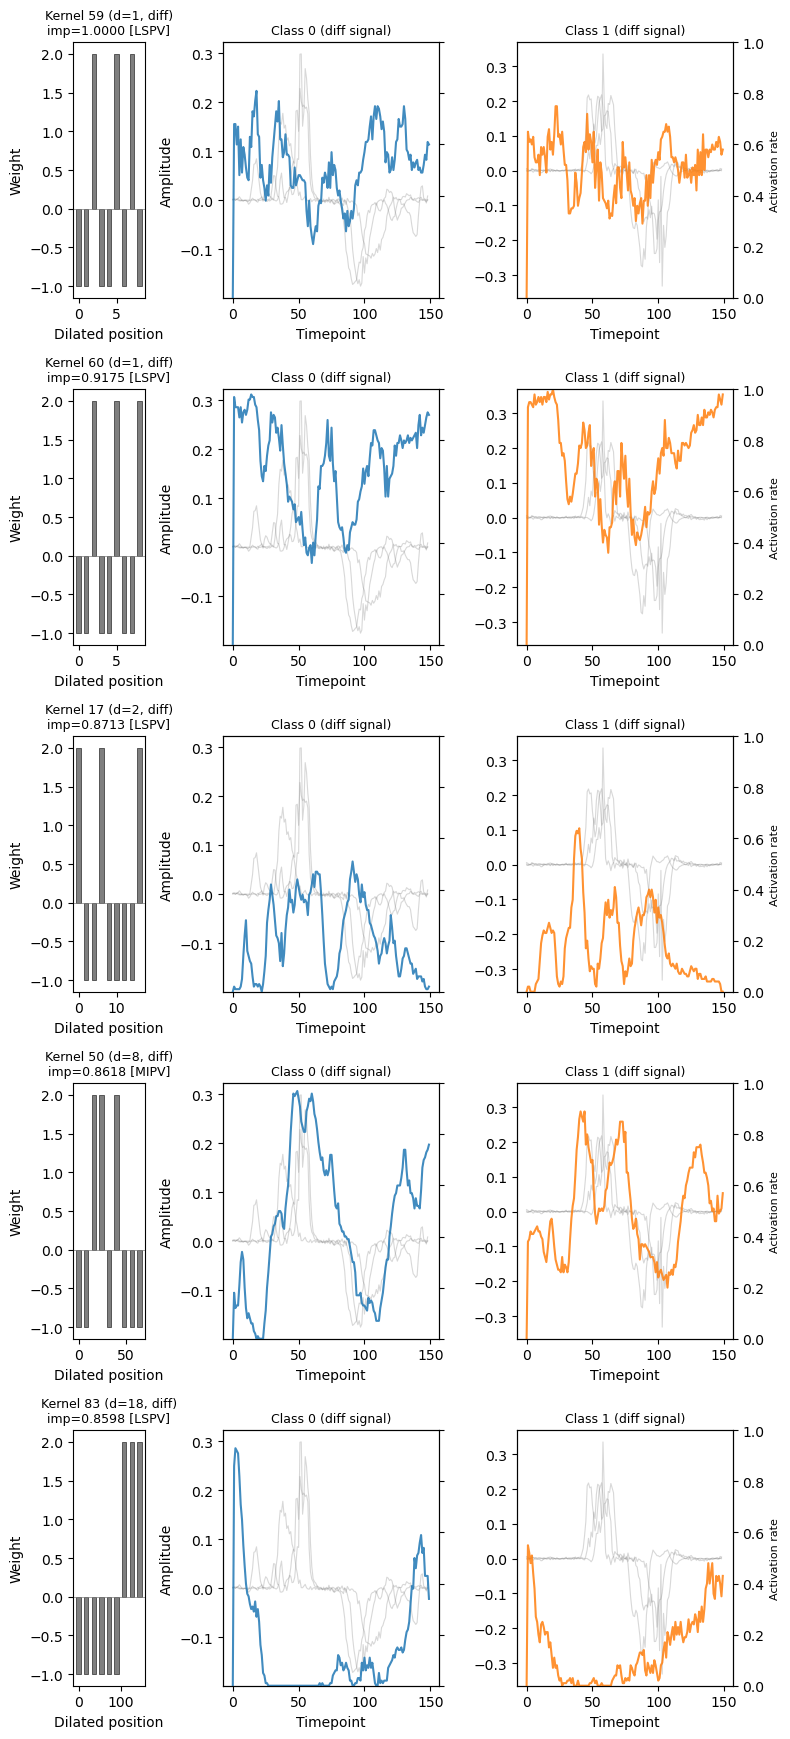

In [8]:
fig = model.plot_top_kernels(
    X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3.5 * min(5, len(stable_features))),
    n_kernels=5,
)

### Feature distributions

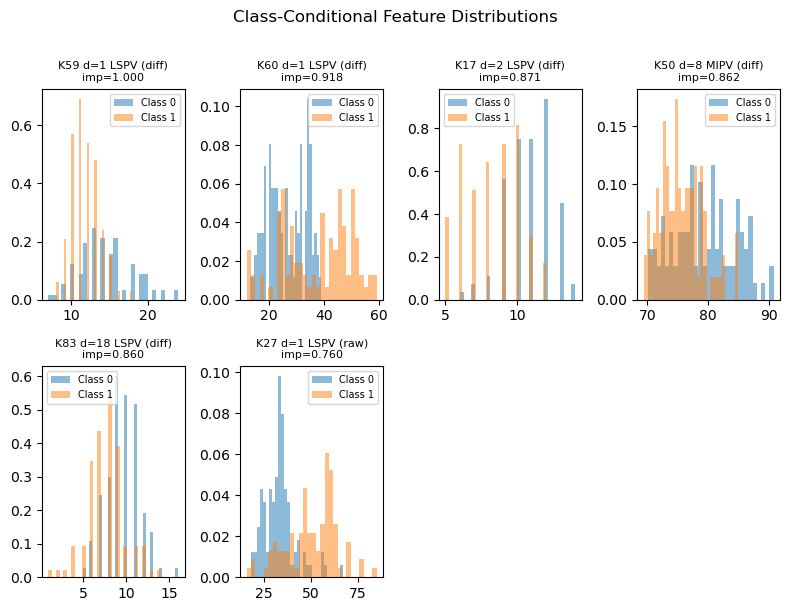

In [9]:
fig = model.plot_feature_distributions(
    X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3 * ((len(stable_features) + 3) // 4)),
)

### Kernel similarity

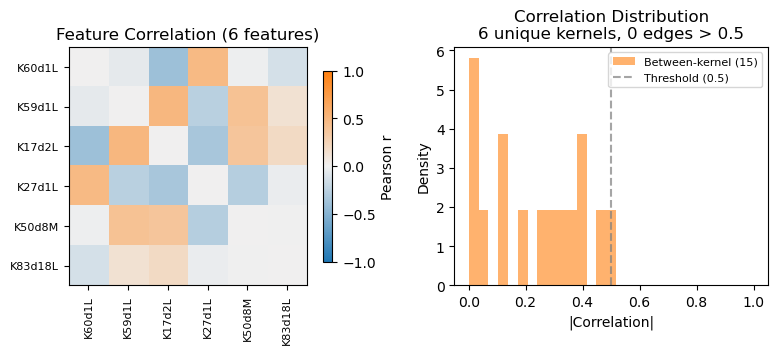

In [10]:
fig, corr = IR.plot_kernel_similarity(
    model, X,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3.5),
)

### Temporal importance

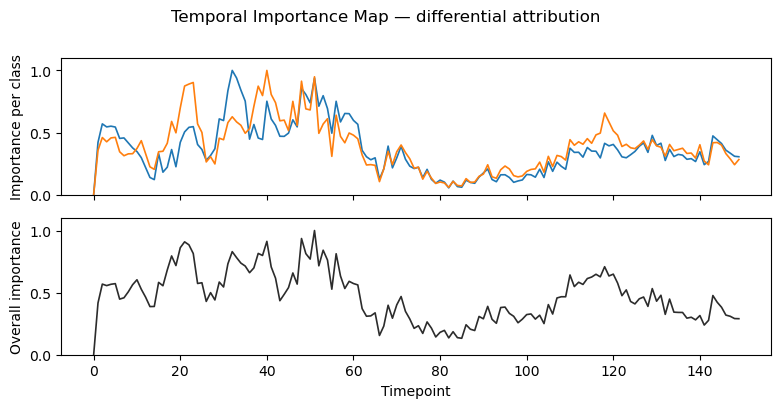

In [11]:
fig, imp_data = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 4),
)

### Receptive field diagram

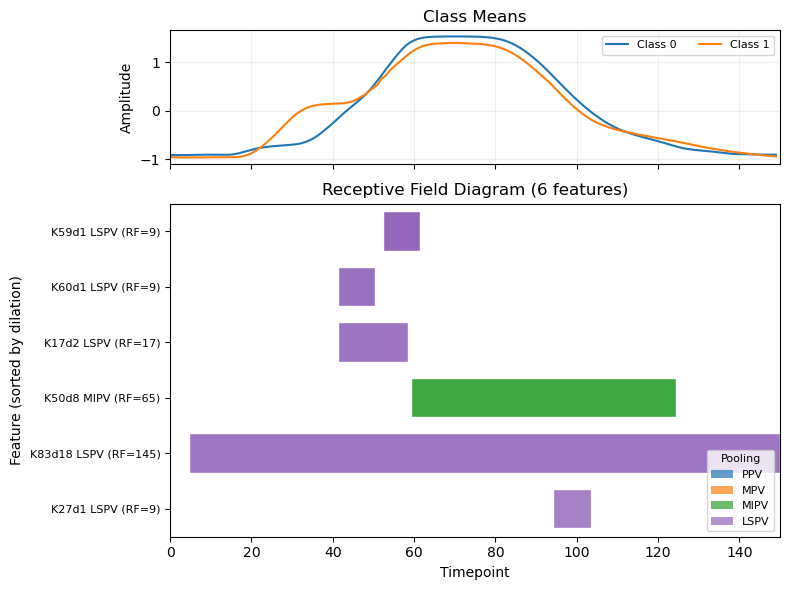

In [12]:
fig = IR.plot_receptive_field_diagram(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 6),
)

## 5. Application to class means

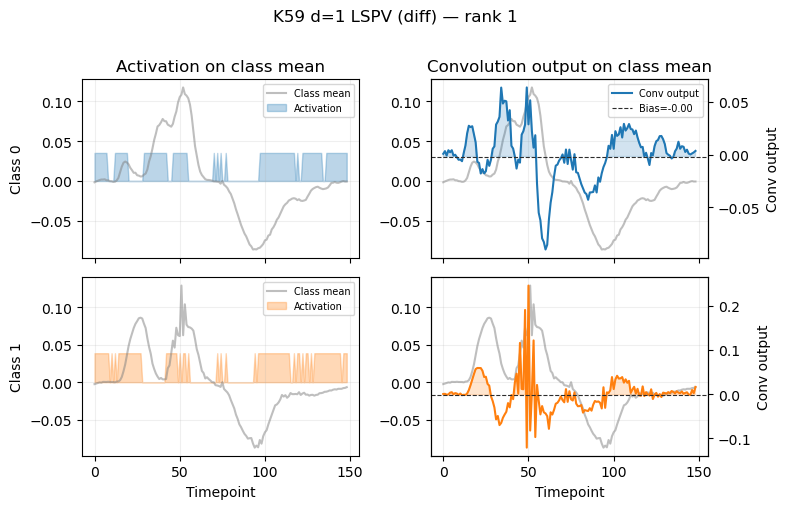

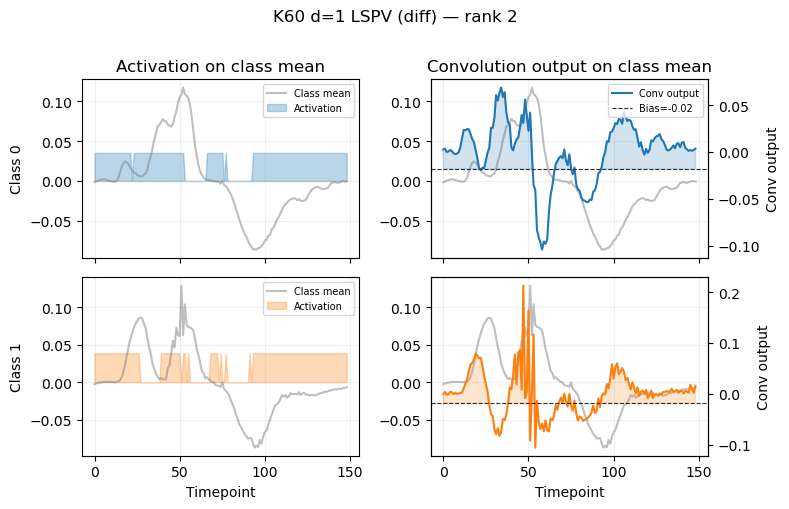

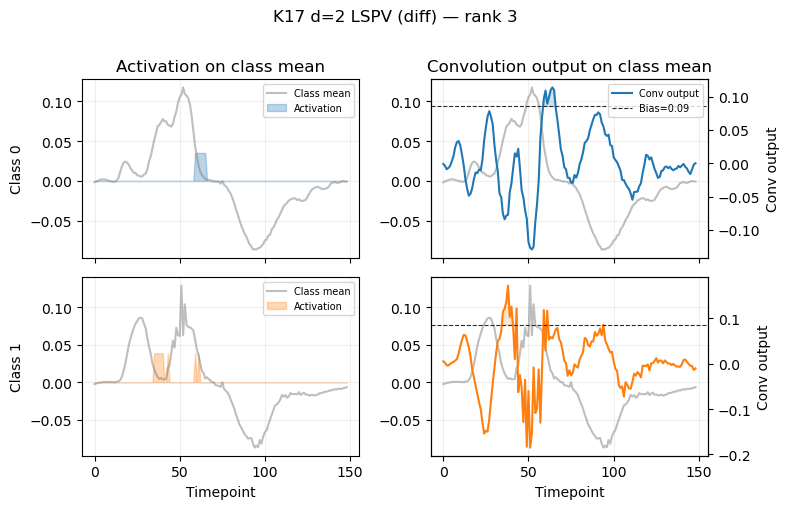

In [13]:
for rank in range(min(3, len(top))):
    fig = IR.plot_class_mean_activation(
        model, X, y,
        feature_mask=stable_features,
        feature_rank=rank,
        figsize=(FIG_WIDTH, 2.5 * len(np.unique(y))),
    )
    plt.show()

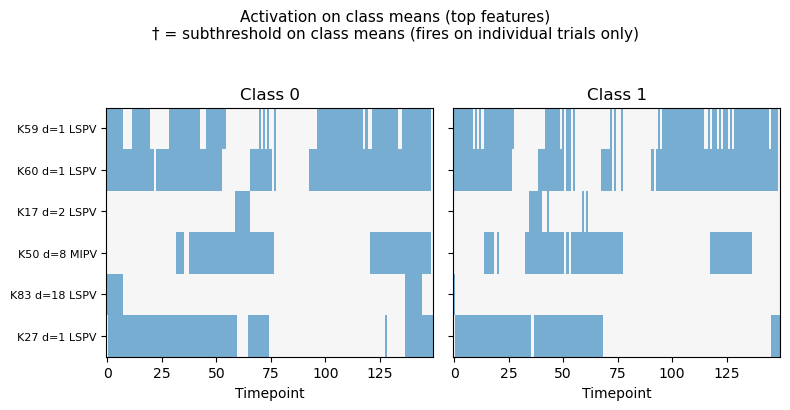

In [14]:
fig = IR.plot_multi_kernel_summary(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 0.4 * min(15, len(stable_features)) + 1.5),
)

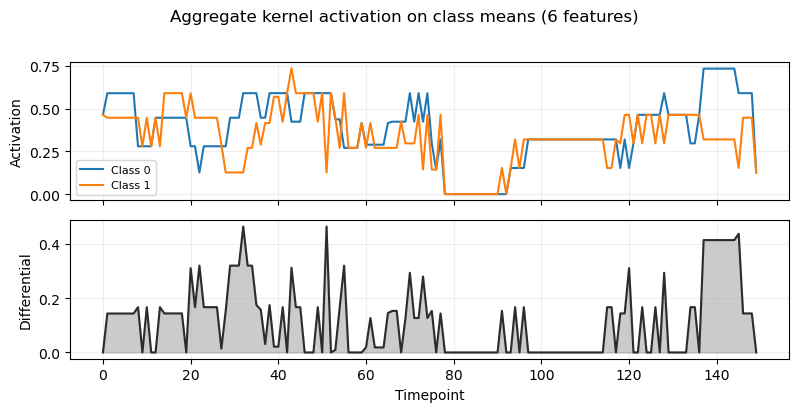

In [15]:
fig, class_act, diff = IR.plot_aggregate_activation(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 4),
)